In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1 A Brief matplotlib API Primer

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
data = np.arange(10)

data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

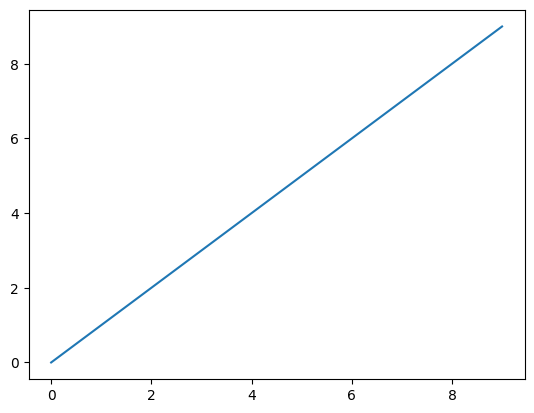

In [ ]:
plt.plot(data)

## 1.1 Figures and Subplots

Plots in matplotlib reside within a `Figure` object. You can create a new figure with `plt.figure`:

In [ ]:
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

`plt.figure` has a number of options; notably, `figsize` will guarantee the figure has a certain size and aspect ratio if saved to disk.

You can’t make a plot with a blank figure. You have to create one or more `subplots` using `add_subplot`:

In [ ]:
# 在一个 2行×2列 的子图网格中，创建并选择第1个子图
ax1 = fig.add_subplot(2, 2, 1)

In [ ]:
ax2 = fig.add_subplot(2, 2, 2)

ax3 = fig.add_subplot(2, 2, 3)

Here we run all of these commands in the same cell:

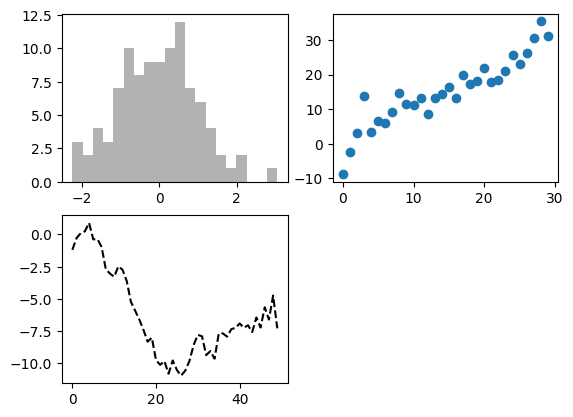

In [ ]:
fig = plt.figure() # 创建画布
ax1 = fig.add_subplot(2, 2, 1) # 在画布中创建 2*2 的子图网格，定位到第一个子图
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)

ax3.plot(np.random.standard_normal(50).cumsum(), color="black", linestyle="dashed")

ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)

ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))

plt.show()

To make creating a grid of subplots more convenient, matplotlib includes a `plt.subplots` method that creates a new figure and returns a NumPy array containing the created subplot objects:

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

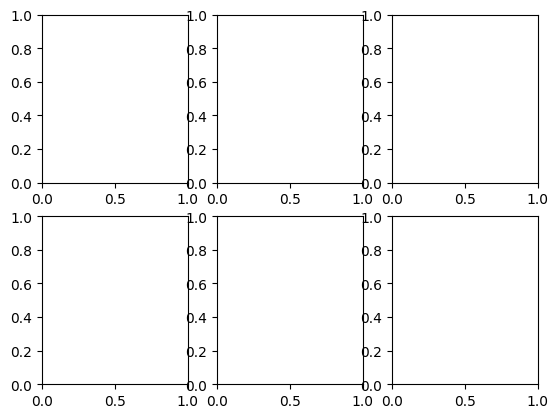

In [ ]:
fig, axes = plt.subplots(2, 3)

axes

## 1.2 Adjusting the spacing around subplots

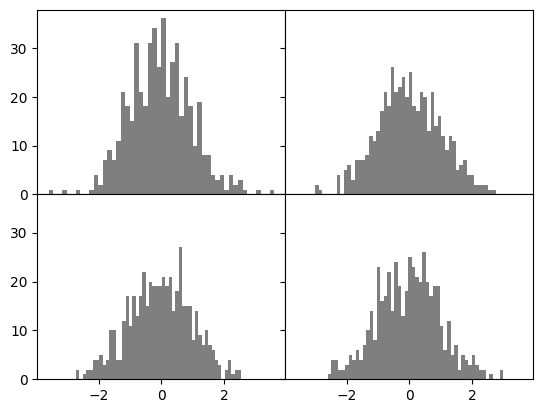

In [ ]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)

for i in range(2):
  for j in range(2):
    axes[i, j].hist(np.random.standard_normal(500), bins=50, color="black", alpha=0.5)

fig.subplots_adjust(wspace=0, hspace=0)

## 1.3 Colors, Markers, and Line Styles

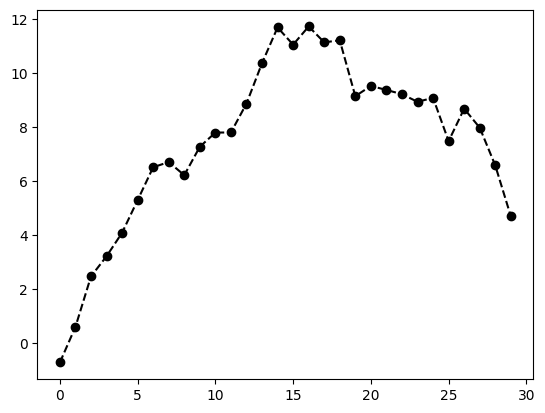

In [ ]:
fig = plt.figure()

ax = fig.add_subplot()

ax.plot(np.random.standard_normal(30).cumsum(), color="black", linestyle="dashed", marker="o")

In [ ]:
plt.close("all")

For line plots, you will notice that subsequent points are linearly interpolated by default. This can be altered with the `drawstyle` option

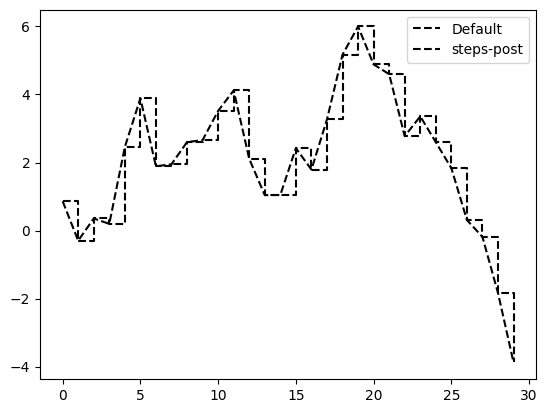

In [ ]:
fig = plt.figure()

ax = fig.add_subplot()

data = np.random.standard_normal(30).cumsum()

ax.plot(data, color="black", linestyle="dashed", label="Default")
ax.plot(data, color="black", linestyle="dashed", drawstyle="steps-post", label="steps-post")

ax.legend()

## 1.4 Ticks, Labels, and Legends

To change the x-axis ticks, it’s easiest to use set_xticks and set_xticklabels. The former instructs matplotlib where to place the ticks along the data range; by default these locations will also be the labels. But we can set any other values as the labels using `set_xticklabels`:

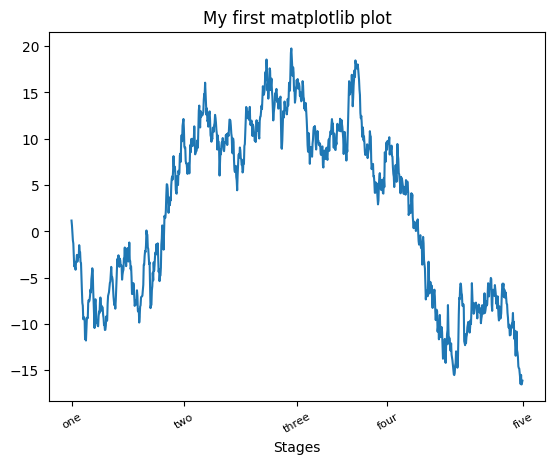

In [ ]:
fig, ax = plt.subplots()

ax.set_xticks([0, 250, 500, 700, 1000])
ax.set_xticklabels(["one", "two", "three", "four", "five"], rotation=30, fontsize=8)
ax.set_xlabel("Stages")
ax.set_title("My first matplotlib plot")


ax.plot(np.random.standard_normal(1000).cumsum())

Adding legends

Legends are another critical element for identifying plot elements. There are a couple of ways to add one. The easiest is to pass the `label` argument when adding each piece of the plot:

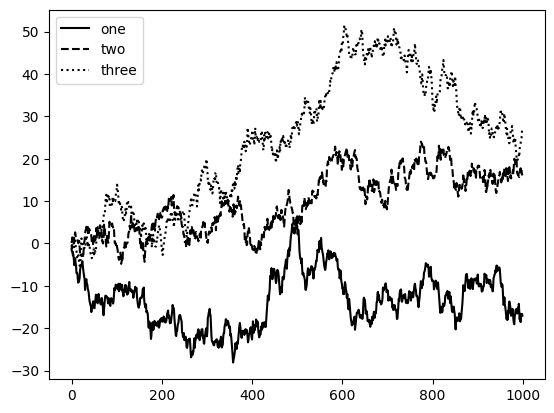

In [ ]:
fig, ax = plt.subplots()

ax.plot(np.random.randn(1000).cumsum(), color="black", label="one")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dashed", label="two")
ax.plot(np.random.randn(1000).cumsum(), color="black", linestyle="dotted", label="three")

ax.legend()

## 1.5 Annotations and Drawing on a Subplot

In addition to the standard plot types, you may wish to draw your own plot annotations, which could consist of text, arrows, or other shapes. You can add annotations and text using the `text, arrow, and annotate` functions. `text` draws text at given coordinates `(x, y)` on the plot with optional custom styling:

Text(0.5, 1.0, 'Important dates in the 2008–2009 financial crisis')

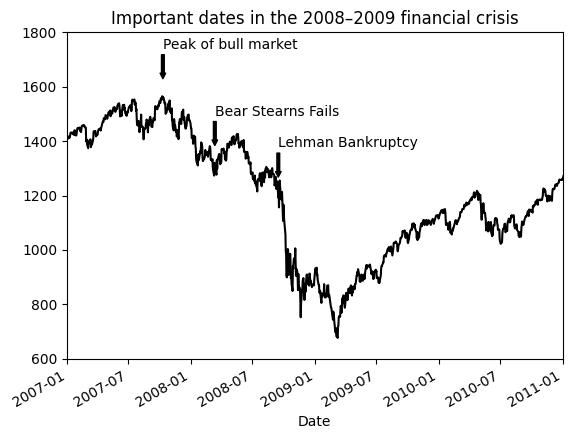

In [ ]:
from datetime import datetime

fig, ax = plt.subplots()

data = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Python for Data Analysis/examples/spx.csv",
                    index_col=0, parse_dates=True)
spx = data["SPX"]

spx.plot(ax=ax, color="black")

crisis_data = [
    (datetime(2007, 10, 11), "Peak of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
  ax.annotate(label, xy=(date, spx.asof(date) + 75),
              xytext=(date, spx.asof(date) + 225),
              arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
              horizontalalignment="left", verticalalignment="top")

ax.set_xlim(["1/1/2007", "1/1/2011"])
ax.set_ylim([600, 1800])

ax.set_title("Important dates in the 2008–2009 financial crisis")

Drawing shapes requires some more care. matplotlib has objects that represent many common shapes, referred to as patches. Some of these, like Rectangle and Circle, are found in matplotlib.pyplot, but the full set is located in `matplotlib.patches`.

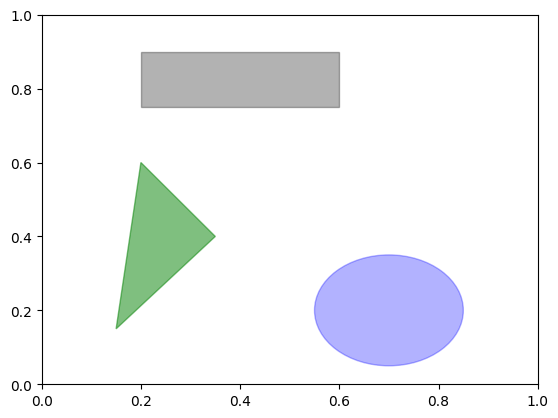

In [ ]:
fig, ax = plt.subplots()

rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color="green", alpha=0.5)

ax.add_patch(rect)
ax.add_patch(circ)
ax.add_patch(pgon)

## 1.6 Saving Plots to File

You can save the active figure to file using the figure object’s `savefig` instance method. For example, to save an SVG version of a figure, you need only type:

In [ ]:
fig.savefig("figpath.svg")

In [ ]:
fig.savefig("figpath.png", dpi=400)

# 2 Plotting with pandas and seaborn

In pandas, we may have multiple columns of data, along with row and column labels. pandas itself has built-in methods that simplify creating visualizations from DataFrame and Series objects. Another library is `seaborn`, a high-level statistical graphics library built on matplotlib. seaborn simplifies creating many common visualization types.

## 2.1 Line Plot

Series and DataFrame have a `plot` attribute for making some basic plot types. By default, `plot()` makes line plots

In [ ]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s

,0
0,-1.002527
10,-1.014646
20,-1.380236
30,-1.888715
40,-2.308610
50,-2.874850
60,-2.125408
70,-1.727647
80,-2.592091
90,-2.380005


<Axes: >

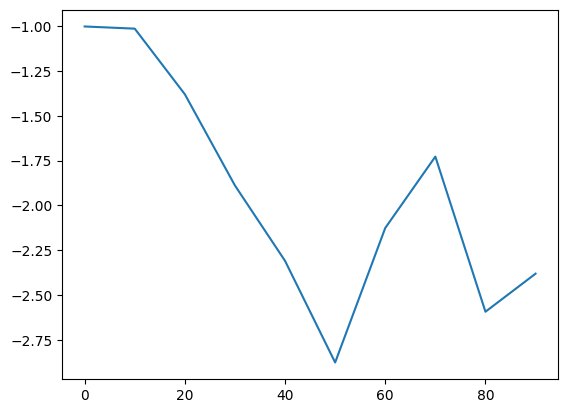

In [ ]:
s.plot()

DataFrame’s plot method plots each of its columns as a different line on the same subplot, creating a legend automatically

In [ ]:
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns = ["A","B","C","D"],
                  index=np.arange(0, 100, 10))

df

,A,B,C,D
0,0.068937,0.984969,-0.830273,-0.666189
10,-0.015874,1.292557,-0.844890,-1.255574
20,-0.274336,0.414245,-1.176184,-0.524295
30,1.464958,1.315084,-1.374179,-0.630021
40,1.897669,2.723289,-0.829390,-1.546182
50,3.683940,4.207365,-2.669449,-2.666906
60,3.594234,3.165265,-2.719541,-1.329263
70,3.563660,3.071372,-1.976069,-2.051845
80,2.640108,3.004093,-0.262124,-1.519008
90,3.110899,1.369243,-0.321852,-2.299494


<Axes: >

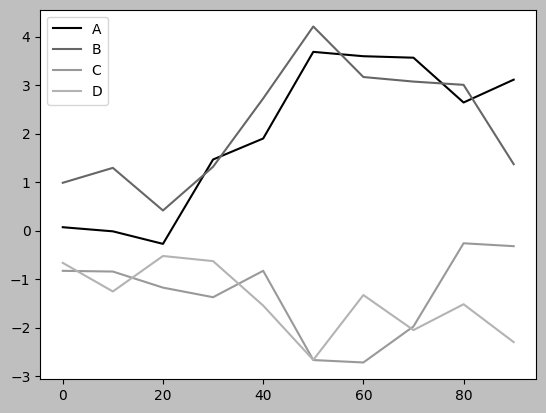

In [ ]:
plt.style.use('grayscale')

df.plot()

## 2.2 Bar Plots

The `plot.bar()` and `plot.barh()` make vertical and horizontal bar plots, respectively. In this case, the Series or DataFrame index will be used as the x (bar) or y (barh) ticks

<Axes: >

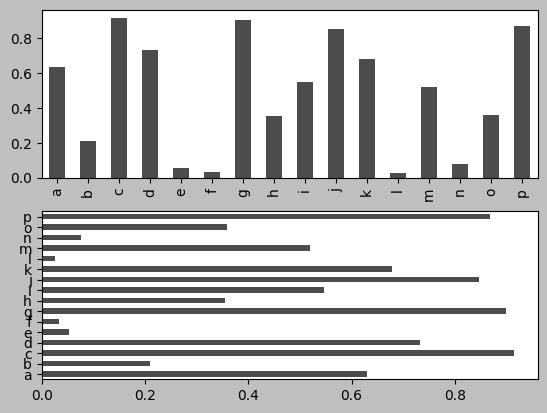

In [ ]:
fig, axes = plt.subplots(2, 1)

data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))

data.plot.bar(ax=axes[0], color="black", alpha=0.7)
data.plot.barh(ax=axes[1], color="black", alpha=0.7)

With a DataFrame, bar plots group the values in each row in bars, side by side, for each value.

In [ ]:
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))

df

Genus,A,B,C,D
one,0.240498,0.481609,0.601449,0.949129
two,0.710606,0.591748,0.803089,0.481048
three,0.552366,0.413915,0.626246,0.579969
four,0.094824,0.394555,0.630388,0.101457
five,0.346071,0.686820,0.549037,0.874769
six,0.465764,0.721519,0.904205,0.463340


<Axes: >

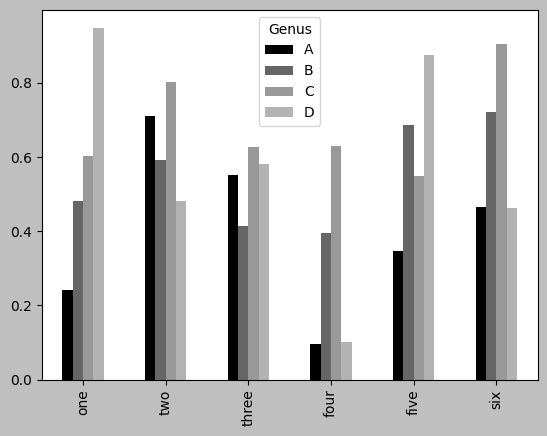

In [ ]:
df.plot.bar()

<Axes: >

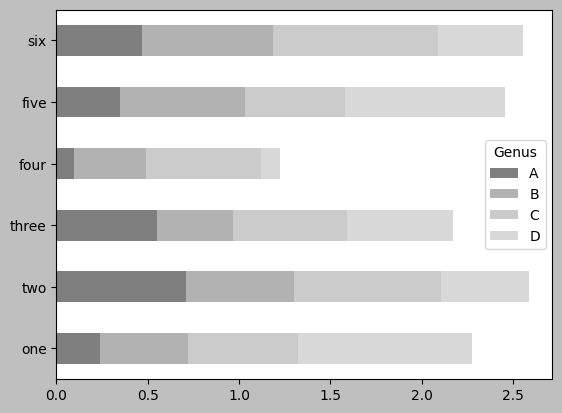

In [ ]:
df.plot.barh(stacked=True, alpha=0.5)

In [ ]:
tips = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Python for Data Analysis/examples/tips.csv")

tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [ ]:
"""
行索引（index）是 tips["day"]（星期几）

列索引（columns）是 tips["size"]（聚餐人数）

返回值：一个 DataFrame，每个单元格表示对应 day 与 size 的出现次数（count）。
"""
party_counts = pd.crosstab(tips["day"], tips["size"])

party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [ ]:
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])

party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


Since there are not many one- and six-person parties, I remove them here:

In [ ]:
party_counts = party_counts.loc[:, 2:5]

party_counts

size,2,3,4,5
day,,,,
Thur,48,4,5,1
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3


Then, normalize so that each row sums to 1, and make the plot

In [ ]:
party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index")

party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

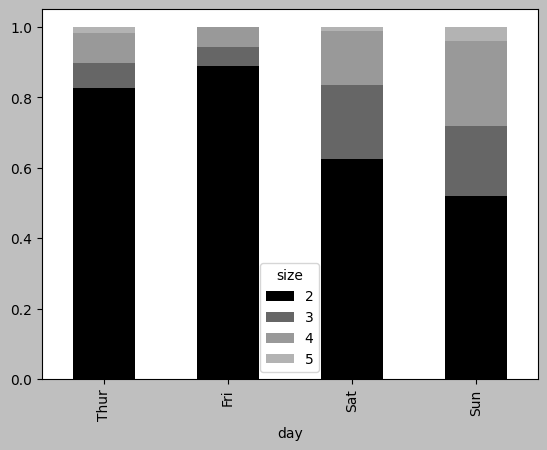

In [ ]:
party_pcts.plot.bar(stacked=True)

With data that requires aggregation or summarization before making a plot, using the `seaborn` package can make things much simpler (install it with conda install seaborn). Let's look now at the tipping percentage by day with seaborn

In [ ]:
import seaborn as sns

tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])

tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

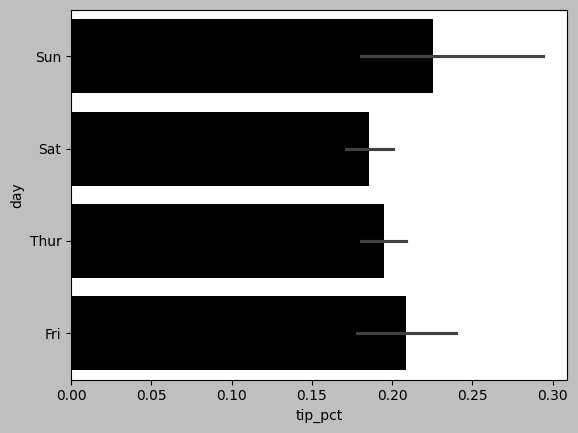

In [ ]:
"""
Seaborn 的 barplot 默认会对数据进行统计汇总（aggregation）。
默认的统计方式是：

对每个 day 计算 tip_pct 的平均值（mean）

然后画出 平均小费率（tip percentage） 的横向条形图。
"""
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")

> Plotting functions in seaborn take a `data` argument, which can be a pandas DataFrame. The other arguments refer to column names. Because there are multiple observations for each value in the `day`, the bars are the average value of `tip_pct`. The black lines drawn on the bars represent the 95% confidence interval

<Axes: xlabel='tip_pct', ylabel='day'>

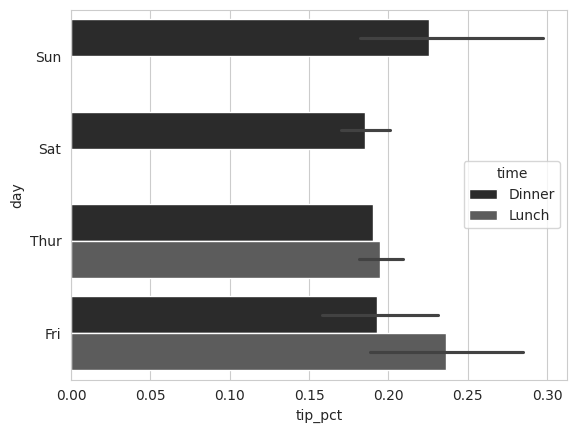

In [ ]:
sns.set_style("whitegrid") # 白色背景 带浅灰色网格线

sns.set_palette("Greys_r") # set_palette() 用来设置所有图表默认的配色方案。"Greys_r" 是一个 反转的灰度调色板

sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

## 2.3 Histograms and Density Plots

A histogram is a kind of bar plot that gives a discretized display of value frequency. The data points are split into discrete, evenly spaced bins, and the number of data points in each bin is plotted. Using the tipping data from before, we can make a histogram of tip percentages of the total bill using the plot.hist method on the Series

<Axes: ylabel='Frequency'>

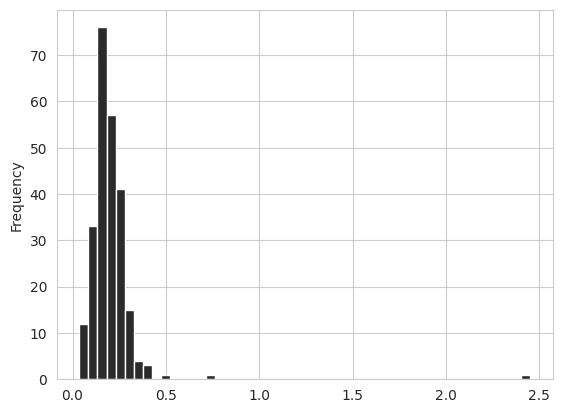

In [ ]:
tips["tip_pct"].plot.hist(bins=50)

A related plot type is a density plot, which is formed by computing an estimate of a continuous probability distribution that might have generated the observed data. The usual procedure is to approximate this distribution as a mixture of "kernels"—that is, simpler distributions like the normal distribution. Thus, density plots are also known as kernel density estimate (KDE) plots. Using `plot.density` makes a density plot using the conventional mixture-of-normals estimate

<Axes: ylabel='Density'>

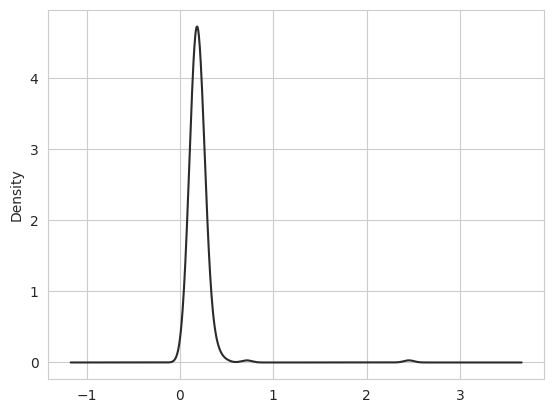

In [ ]:
tips["tip_pct"].plot.density() # 想象成：平滑版的直方图（histogram）。

seaborn makes histograms and density plots even easier through its histplot method, which can plot both a histogram and a continuous density estimate simultaneously. As an example, consider a bimodal distribution consisting of draws from two different standard normal distributions

In [ ]:
comp1 = np.random.standard_normal(200)

comp2 = 10 + 2 * np.random.standard_normal(200)

values = pd.Series(np.concatenate([comp1, comp2]))

values

,0
0,0.184133
1,-1.305761
2,-0.959654
3,0.581507
4,-0.248384
...,...
395,13.001983
396,7.773748
397,10.056540
398,11.640657


<Axes: ylabel='Count'>

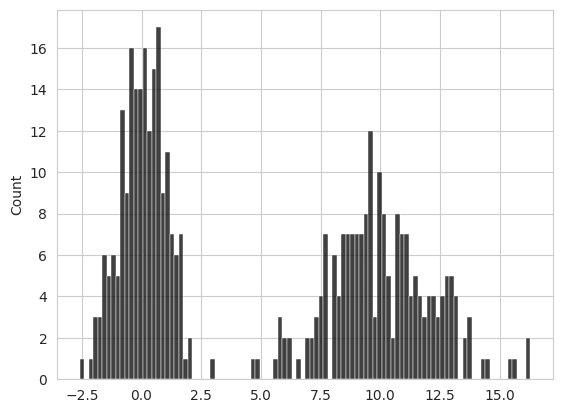

In [ ]:
sns.histplot(values, bins=100, color="black")

## 2.4 Scatter Plots

Point plots or scatter plots can be a useful way of examining the relationship between two one-dimensional data series. For example, here we load the `macrodata` dataset from the statsmodels project, select a few variables, then compute log differences:

In [ ]:
macro = pd.read_csv("/content/drive/My Drive/Colab Notebooks/Python for Data Analysis/examples/macrodata.csv")

data = macro[["cpi", "m1", "tbilrate", "unemp"]]

data.tail()

,cpi,m1,tbilrate,unemp
198,216.889,1474.7,1.17,6.0
199,212.174,1576.5,0.12,6.9
200,212.671,1592.8,0.22,8.1
201,214.469,1653.6,0.18,9.2
202,216.385,1673.9,0.12,9.6


In [ ]:
# .diff() 默认是：x_t- x_{t-1}

# 数据经过 log 转换后的一阶差分 → 对数收益率序列
trans_data = np.log(data).diff().dropna()

trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


We can then use seaborn's `regplot` method, which makes a scatter plot and fits a linear regression line

Text(0.5, 1.0, 'Changes in log(m1) versus log(unemp)')

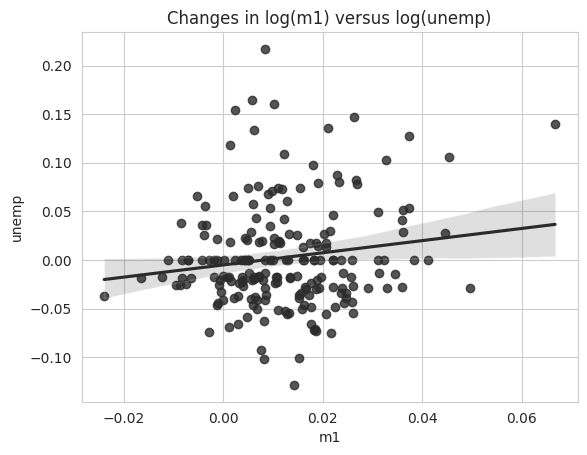

In [ ]:
ax = sns.regplot(x="m1", y="unemp", data=trans_data)

ax.set_title("Changes in log(m1) versus log(unemp)")

In exploratory data analysis, it’s helpful to be able to look at all the scatter plots among a group of variables; this is known as a pairs plot or scatter plot matrix. Making such a plot from scratch is a bit of work, so seaborn has a convenient pairplot function that supports placing histograms or density estimates of each variable along the diagonal

**Pair plot / Scatter Plot Matrix**：  
对数据框中每一对变量绘制散点图（scatter plot），同时在对角线上绘制每个变量的分布（histogram 或 KDE）。  
用途：
1. 快速查看变量之间的关系（相关性、线性趋势、异常值等）
2. 观察每个变量的分布情况
3. EDA（Exploratory Data Analysis，探索性数据分析）常用手段

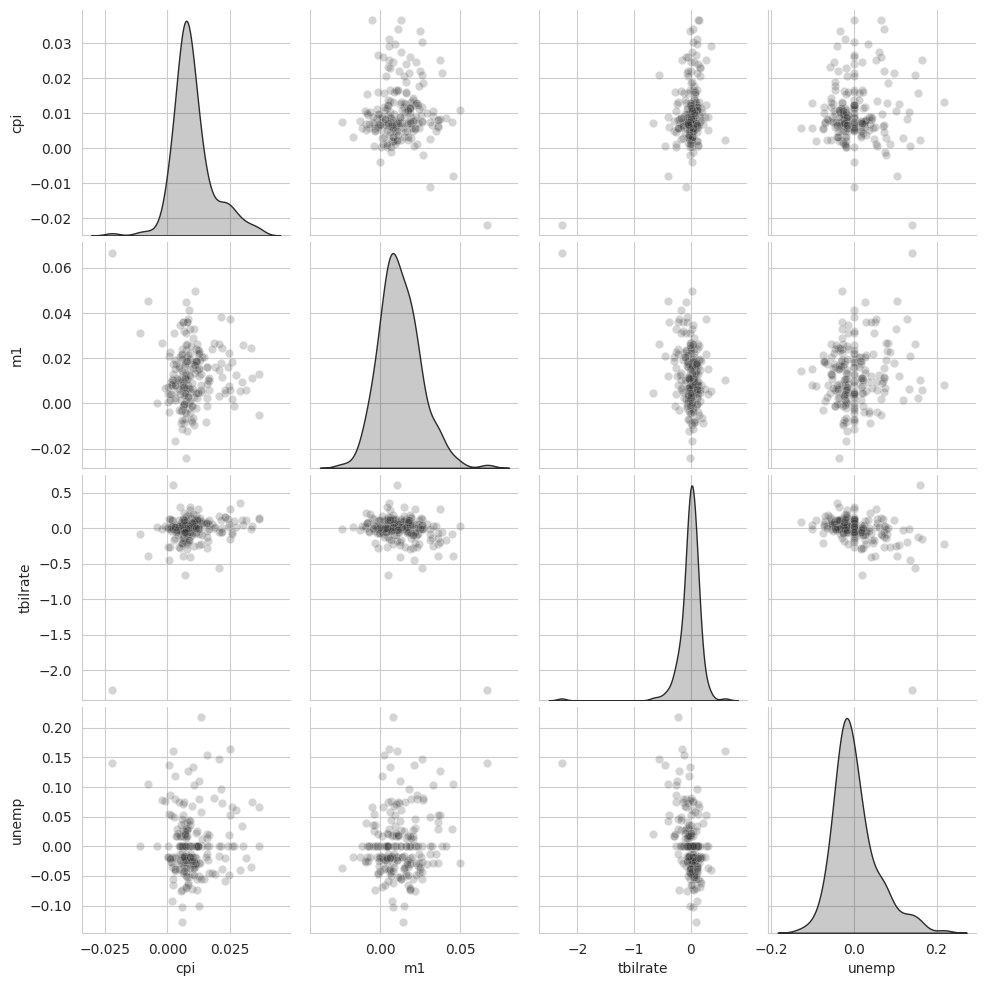

In [ ]:
"""
diag_kind="kde"
  对角线（diagonal）默认绘制每个变量的分布
  可选值：
    "hist" → 直方图
    "kde" → 核密度估计曲线（平滑曲线）

plot_kws={"alpha": 0.2}
  plot_kws 是传给散点图的参数字典
  "alpha": 0.2 控制透明度，数值越小越透明（0=完全透明，1=不透明）
"""
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

## 2.5 Facet Grids and Categorical Data

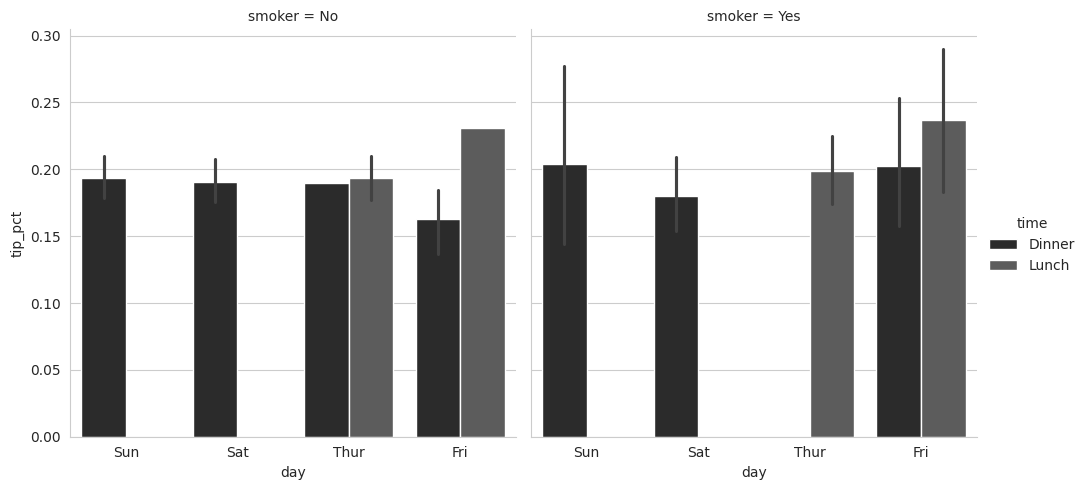

In [ ]:
"""
col="smoker"
  按 smoker 列（Yes / No）拆分列方向子图
  生成两张图：
    吸烟者（smoker=Yes）
    非吸烟者（smoker=No）
"""
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker", kind="bar", data=tips[tips.tip_pct < 1])

Instead of grouping by `"time"` by different bar colors within a facet, we can also expand the facet grid by adding one row per `time` value

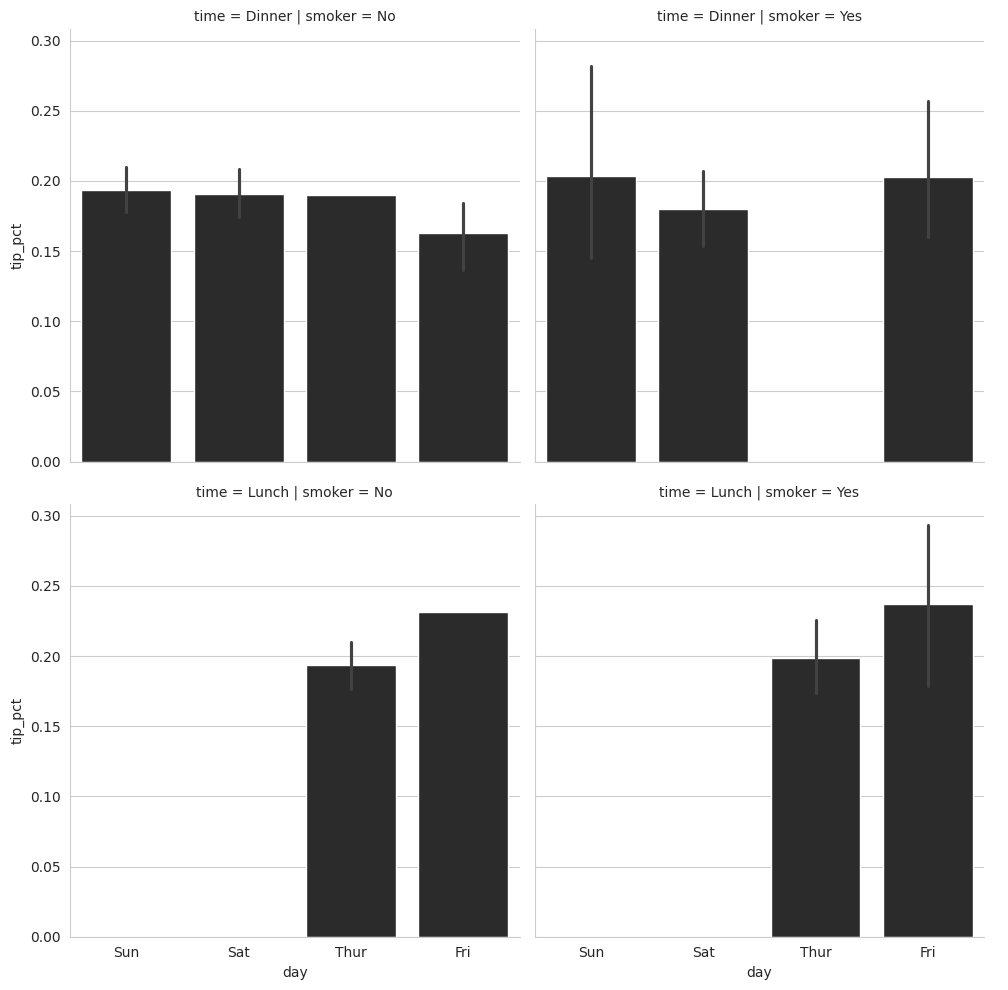

In [ ]:
sns.catplot(x="day", y="tip_pct",
            row="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])

catplot supports other plot types that may be useful depending on what you are trying to display. For example, `box plots`

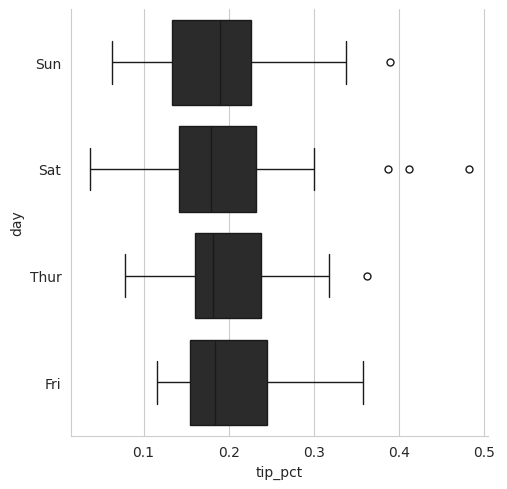

In [ ]:
sns.catplot(x="tip_pct", y="day", kind="box", data=tips[tips.tip_pct < 0.5])